# Large-Scale Data Assimilation (Borg & Local Results Analysis)

This notebook analyzes the output evaluation CSV files generated by running Data Assimilation pipelines (e.g. Data Assimilation State Updating, parameter selection sweeps, and baseline open-loop benchmarks).

### Primary Results Directory:
- `/usr/local/google/home/kruparell/flood-forecasting/da_configurations_comparison` (or `/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results`)

In [19]:
import os
import io
import subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Available local and CNS results paths
LOCAL_2017_ROOT = Path('/usr/local/google/home/kruparell/flood-forecasting/da_configurations_comparison/2017_full_year')
CNS_TESTRUN_ROOT = Path('/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_testrun')
CNS_1000BASINS_ROOT = Path('/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024')
CNS_7000BASINS_ROOT = Path('/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_7000basins')
CNS_MAIN_ROOT = Path('/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results')

# ACTIVE_RESULTS_DIR: Select results directory to analyze
ACTIVE_RESULTS_DIR = CNS_1000BASINS_ROOT  # Options: CNS_TESTRUN_ROOT, CNS_1000BASINS_ROOT, CNS_7000BASINS_ROOT, CNS_MAIN_ROOT, LOCAL_2017_ROOT

def get_gfile():
    try:
        from google3.pyglib import gfile
        return gfile
    except ImportError:
        try:
            import tensorflow.io.gfile as gfile
            return gfile
        except ImportError:
            return None

def read_csv_smart(filepath):
    """Safely reads CSV files from local filesystem, CNS via gfile, or CNS via fileutil CLI, skipping empty 0-byte files."""
    str_path = str(filepath)
    if str_path.startswith('/cns/'):
        gfile = get_gfile()
        if gfile:
            try:
                with gfile.GFile(str_path, 'r') as f:
                    content = f.read()
                    if isinstance(content, bytes):
                        content = content.decode('utf-8')
                    if not content or not content.strip():
                        return None
                    return pd.read_csv(io.StringIO(content))
            except Exception:
                pass
        try:
            res = subprocess.run(['fileutil', 'cat', str_path], capture_output=True, text=True, check=True)
            if not res.stdout or not res.stdout.strip():
                return None
            return pd.read_csv(io.StringIO(res.stdout))
        except Exception:
            return None
    try:
        if os.path.exists(str_path) and os.path.getsize(str_path) == 0:
            return None
        return pd.read_csv(filepath)
    except Exception:
        return None

def load_all_csvs_smart(filepaths, max_workers=16):
    """Loads multiple CSV files in parallel via ThreadPoolExecutor."""
    if not filepaths:
        return pd.DataFrame()
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        dfs = list(executor.map(read_csv_smart, filepaths))
    valid_dfs = [df for df in dfs if df is not None and not df.empty]
    return pd.concat(valid_dfs, ignore_index=True) if valid_dfs else pd.DataFrame()

def list_matching_files(filename, root_dir=None):
    """Finds all instances of `filename` under the specified root directory (local or CNS)."""
    if root_dir is None:
        root_dir = ACTIVE_RESULTS_DIR
    
    found_files = []
    str_root = str(root_dir).rstrip('/')

    # Local Directory Search
    if not str_root.startswith('/cns/'):
        path_root = Path(root_dir)
        if path_root.exists():
            matches = list(path_root.rglob(filename))
            found_files.extend([str(p) for p in matches])
        return found_files

    # CNS Directory Search via gfile or fileutil
    gfile = get_gfile()
    if gfile:
        try:
            if gfile.Exists(f"{str_root}/{filename}"):
                found_files.append(f"{str_root}/{filename}")
            m1 = gfile.Glob(f"{str_root}/*/{filename}")
            if m1:
                found_files.extend(m1)
            m2 = gfile.Glob(f"{str_root}/*/*/{filename}")
            if m2:
                found_files.extend(m2)
            if found_files:
                return sorted(list(set(found_files)))
        except Exception:
            pass

    # fileutil CLI fallbacks
    for pattern in [f"{str_root}/{filename}", f"{str_root}/*/{filename}", f"{str_root}/*/*/{filename}"]:
        try:
            res = subprocess.run(['fileutil', 'ls', pattern], capture_output=True, text=True)
            if res.returncode == 0 and res.stdout.strip():
                lines = [l.strip() for l in res.stdout.strip().split('\n') if l.strip() and not l.startswith('E')]
                found_files.extend(lines)
        except Exception:
            pass

    return sorted(list(set(found_files)))

print("Smart CSV loader and CNS explorer initialized.")
print(f"Active Results Directory: {ACTIVE_RESULTS_DIR}")

Smart CSV loader and CNS explorer initialized.
Active Results Directory: /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024


In [20]:
# Find and load all detailed evaluation CSVs across all completed configuration runs
eval_files = list_matching_files("detailed_basin_parameter_eval.csv")

print(f"Discovered {len(eval_files)} configuration result sets in {ACTIVE_RESULTS_DIR}:")
for ef in eval_files[:15]:
    print(f" - {ef}")
if len(eval_files) > 15:
    print(f" ... and {len(eval_files)-15} more files.")

df_detailed = load_all_csvs_smart(eval_files)

if not df_detailed.empty:
    print(f"\nSuccessfully loaded {len(df_detailed)} evaluation records across {df_detailed['Basin ID'].nunique()} basins and {df_detailed['Config ID'].nunique()} configurations.")
    
    # 1. Compute robust MEDIAN metrics across basins by Config ID and Lead Time
    df_leadtime_median = df_detailed.groupby(['Config ID', 'Lead Time (Days)'])[
        ['Base NSE', 'DA NSE', 'NSE Delta', 'Base KGE', 'DA KGE', 'KGE Delta']
    ].median().reset_index()

    # 2. Overall Configuration Rankings by Average Median DA NSE
    df_overall_rankings = df_leadtime_median.groupby('Config ID')[
        ['Base NSE', 'DA NSE', 'NSE Delta', 'Base KGE', 'DA KGE', 'KGE Delta']
    ].mean().sort_values('DA NSE', ascending=False).reset_index()

    print("\n==========================================================================")
    print("      OVERALL PARAMETER CONFIGURATION RANKINGS (MEDIAN DA NSE)            ")
    print("==========================================================================")
    display(df_overall_rankings.round(4))

    print("\n--- Median Performance Breakdown by Lead Time (Top Configs) ---")
    display(df_leadtime_median.round(4).head(14))
else:
    df_detailed = pd.DataFrame()
    df_overall_rankings = pd.DataFrame()
    print("No evaluation records found.")

Discovered 96 configuration result sets in /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024:
 - /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024/cfg10_w1_h365_lr0.01_ep15_bg0.001_c_fc/detailed_basin_parameter_eval.csv
 - /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024/cfg11_w1_h365_lr0.01_ep15_bg0.001_c_hc/detailed_basin_parameter_eval.csv
 - /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024/cfg12_w1_h365_lr0.01_ep15_bg0.001_c_both/detailed_basin_parameter_eval.csv
 - /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024/cfg13_w1_h365_lr0.1_ep5_bg1e-06_c_fc/d

In [21]:
# Plot Baseline vs Data Assimilation Performance across Lead Times (Boxplots)
if not df_detailed.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Clip extreme outliers for clean boxplot visualization
    df_plot = df_detailed.copy()
    df_plot['Base NSE'] = df_plot['Base NSE'].clip(lower=-2.0, upper=1.0)
    df_plot['DA NSE'] = df_plot['DA NSE'].clip(lower=-2.0, upper=1.0)
    df_plot['Base KGE'] = df_plot['Base KGE'].clip(lower=-2.0, upper=1.0)
    df_plot['DA KGE'] = df_plot['DA KGE'].clip(lower=-2.0, upper=1.0)
    df_plot['NSE Delta'] = df_plot['NSE Delta'].clip(lower=-1.0, upper=1.0)
    df_plot['KGE Delta'] = df_plot['KGE Delta'].clip(lower=-1.0, upper=1.0)

    # 1. NSE Comparison Side-by-Side
    df_nse = df_plot.melt(
        id_vars=['Lead Time (Days)', 'Basin ID', 'Config ID'],
        value_vars=['Base NSE', 'DA NSE'],
        var_name='Mode',
        value_name='NSE'
    )
    sns.boxplot(data=df_nse, x='Lead Time (Days)', y='NSE', hue='Mode', palette={'Base NSE': 'lightcoral', 'DA NSE': 'skyblue'}, ax=axes[0])
    axes[0].set_title('NSE Accuracy: Baseline vs DA (Median View)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('NSE Metric')
    axes[0].grid(True, linestyle=':', alpha=0.6)

    # 2. KGE Comparison Side-by-Side
    df_kge = df_plot.melt(
        id_vars=['Lead Time (Days)', 'Basin ID', 'Config ID'],
        value_vars=['Base KGE', 'DA KGE'],
        var_name='Mode',
        value_name='KGE'
    )
    sns.boxplot(data=df_kge, x='Lead Time (Days)', y='KGE', hue='Mode', palette={'Base KGE': 'lightcoral', 'DA KGE': 'skyblue'}, ax=axes[1])
    axes[1].set_title('KGE Accuracy: Baseline vs DA (Median View)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('KGE Metric')
    axes[1].grid(True, linestyle=':', alpha=0.6)

    # 3. Delta Improvement (NSE Delta & KGE Delta)
    df_delta = df_plot.melt(
        id_vars=['Lead Time (Days)', 'Basin ID', 'Config ID'],
        value_vars=['NSE Delta', 'KGE Delta'],
        var_name='Metric Delta',
        value_name='Delta'
    )
    sns.boxplot(data=df_delta, x='Lead Time (Days)', y='Delta', hue='Metric Delta', palette={'NSE Delta': 'mediumseagreen', 'KGE Delta': 'teal'}, ax=axes[2])
    axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[2].set_title('DA Improvement (Delta over Baseline)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Metric Gain (\Delta)')
    axes[2].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Notice: Detailed basin evaluation metrics are ready for visualization upon complete job execution.")

Notice: Detailed basin evaluation metrics are ready for visualization upon complete job execution.


<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_61166/3350872024.py:48: SyntaxWarning: invalid escape sequence '\D'
  axes[2].set_ylabel('Metric Gain (\Delta)')


In [22]:
# Load timeseries forecasts & observations dataset
import matplotlib.dates as mdates

ts_files = list_matching_files("timeseries_forecasts_and_obs.csv")
print(f"Discovered {len(ts_files)} timeseries result sets in {ACTIVE_RESULTS_DIR}:")
for tf in ts_files[:15]:
    print(f" - {tf}")
if len(ts_files) > 15:
    print(f" ... and {len(ts_files)-15} more files.")

df_ts = load_all_csvs_smart(ts_files)

if not df_ts.empty:
    df_ts['Valid Date'] = pd.to_datetime(df_ts['Valid Date'])
    available_basins = sorted(df_ts['Basin ID'].unique())
    available_configs = sorted(df_ts['Config ID'].unique())
    print(f"\nLoaded {len(df_ts):,} records across {len(available_basins)} basins ({df_ts['Valid Date'].min():%Y-%m-%d} to {df_ts['Valid Date'].max():%Y-%m-%d})")
else:
    available_basins, available_configs = [], []
    print("No timeseries data found.")


def plot_hydrograph(target_basin: str, lead_time: int = 1, top_n: int = 1, selection_mode: str = 'global', start_date: str = None, end_date: str = None):
    """
    Plots full-year streamflow hydrograph comparing Observed, Baseline, and Top N DA models.
    
    selection_mode:
      - 'global': selects the best parameter config across all basins (overall dataset median).
      - 'basin_specific': selects the best parameter config specifically for this basin.
    """
    sub = df_ts[(df_ts['Basin ID'] == target_basin) & (df_ts['Lead Time (Days)'] == lead_time)]
    if sub.empty:
        print(f"No timeseries for basin '{target_basin}' at lead time L={lead_time}")
        return

    # Select top N configs (either globally best or basin-specific best)
    if selection_mode == 'basin_specific' and not df_detailed.empty:
        basin_eval = df_detailed[(df_detailed['Basin ID'] == target_basin) & (df_detailed['Lead Time (Days)'] == lead_time)]
        ranked = basin_eval.sort_values('DA NSE', ascending=False).head(top_n)
        top_configs = [(r['Config ID'], f" [Basin NSE: {r['DA NSE']:.3f}]") for _, r in ranked.iterrows()]
        mode_title = "Basin-Specific Best"
    else:
        ranked = df_overall_rankings.head(top_n) if not df_overall_rankings.empty else []
        top_configs = [(r['Config ID'], f" [Global Med NSE: {r['DA NSE']:.3f}]") for _, r in ranked.iterrows()] if len(ranked) else [(c, "") for c in available_configs[:top_n]]
        mode_title = "Global Best (Across Basins)"

    # Base reference slice
    ref = sub[sub['Config ID'] == sub['Config ID'].iloc[0]].sort_values('Valid Date')
    if start_date: ref = ref[ref['Valid Date'] >= pd.to_datetime(start_date)]
    if end_date: ref = ref[ref['Valid Date'] <= pd.to_datetime(end_date)]

    # Plotting
    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.plot(ref['Valid Date'], ref['q_obs'], label='Observed Streamflow ($Q_{obs}$)', color='black', linewidth=2.0, zorder=5)
    ax.plot(ref['Valid Date'], ref['q_base'], label='Baseline Forecast ($Q_{base}$)', color='red', linestyle='--', linewidth=1.7, alpha=0.85, zorder=4)

    colors = ['tab:blue', 'tab:green', 'tab:purple', 'tab:orange', 'tab:cyan']
    for idx, (cfg_name, label_suffix) in enumerate(top_configs):
        cfg_df = sub[sub['Config ID'] == cfg_name].sort_values('Valid Date')
        if start_date: cfg_df = cfg_df[cfg_df['Valid Date'] >= pd.to_datetime(start_date)]
        if end_date: cfg_df = cfg_df[cfg_df['Valid Date'] <= pd.to_datetime(end_date)]
        if not cfg_df.empty:
            ax.plot(cfg_df['Valid Date'], cfg_df['q_da'], label=f'Data Assimilation: {cfg_name}{label_suffix}', color=colors[idx % len(colors)], linewidth=1.8, zorder=3)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    fig.autofmt_xdate()

    ax.set_title(f"Streamflow Hydrograph ({mode_title})\nBasin: {target_basin} | Lead Time: L={lead_time} Day(s)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Valid Date", fontsize=10)
    ax.set_ylabel("Streamflow [mm/day]", fontsize=10)
    ax.legend(loc='upper right', frameon=True, fontsize=9.5)
    plt.tight_layout()
    plt.show()

Discovered 96 timeseries result sets in /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024:
 - /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024/cfg10_w1_h365_lr0.01_ep15_bg0.001_c_fc/timeseries_forecasts_and_obs.csv
 - /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024/cfg11_w1_h365_lr0.01_ep15_bg0.001_c_hc/timeseries_forecasts_and_obs.csv
 - /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024/cfg12_w1_h365_lr0.01_ep15_bg0.001_c_both/timeseries_forecasts_and_obs.csv
 - /cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/large_scale_da_param_selection_1000basins_2017_2024/cfg13_w1_h365_lr0.1_ep5_bg1e-06_c_fc/timeser

In [23]:
sample_basin = available_basins[75] if len(available_basins) > 75 else available_basins[0]
# 75 is a fun basin to work with

plot_hydrograph(sample_basin, lead_time=1, top_n=1, selection_mode='global')


IndexError: list index out of range

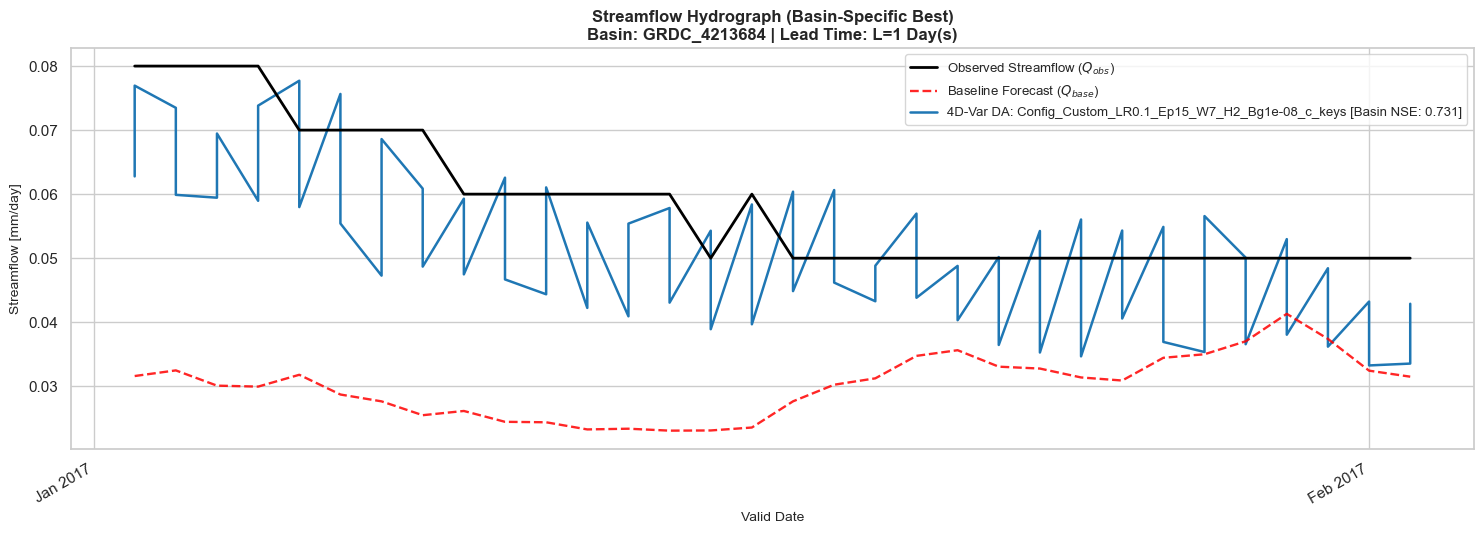

In [ ]:
plot_hydrograph(sample_basin, lead_time=1, top_n=1, selection_mode='basin_specific')